import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

loading dataset

In [6]:
df = pd.read_csv("/content/diabetes.csv")

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


exploratory data analysis(EDA)

In [11]:
df.shape

(768, 9)

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


finding missing values

In [14]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

(df[cols]==0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


histograms

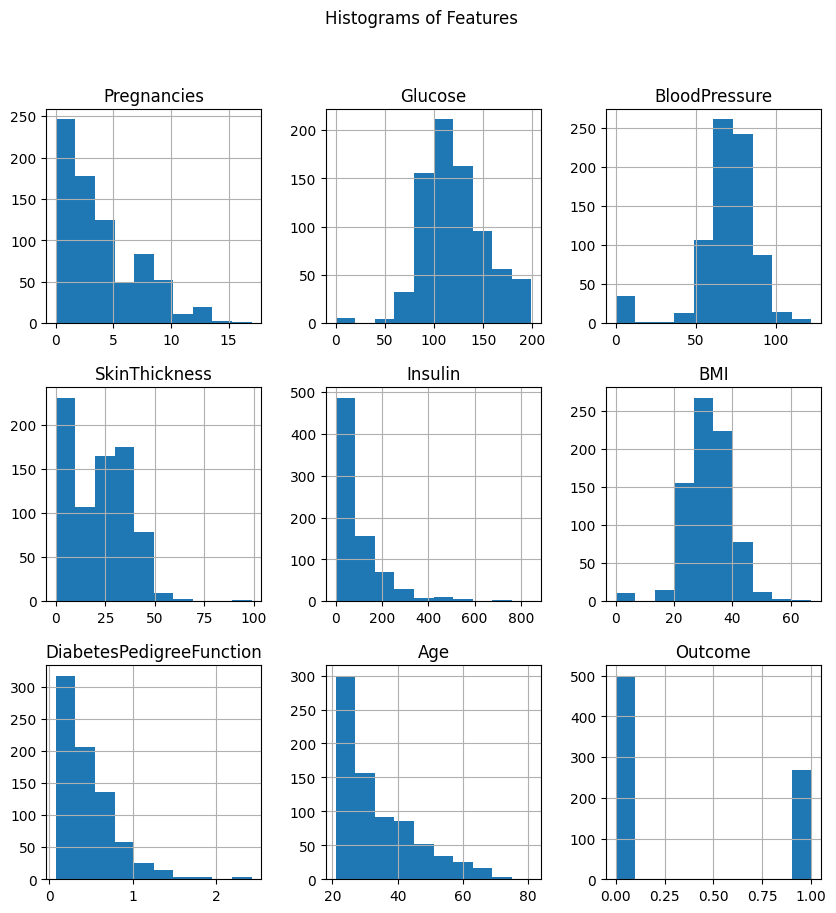

In [16]:
df.hist(figsize=(10,10))
plt.suptitle("Histograms of Features")
plt.show()

boxplots

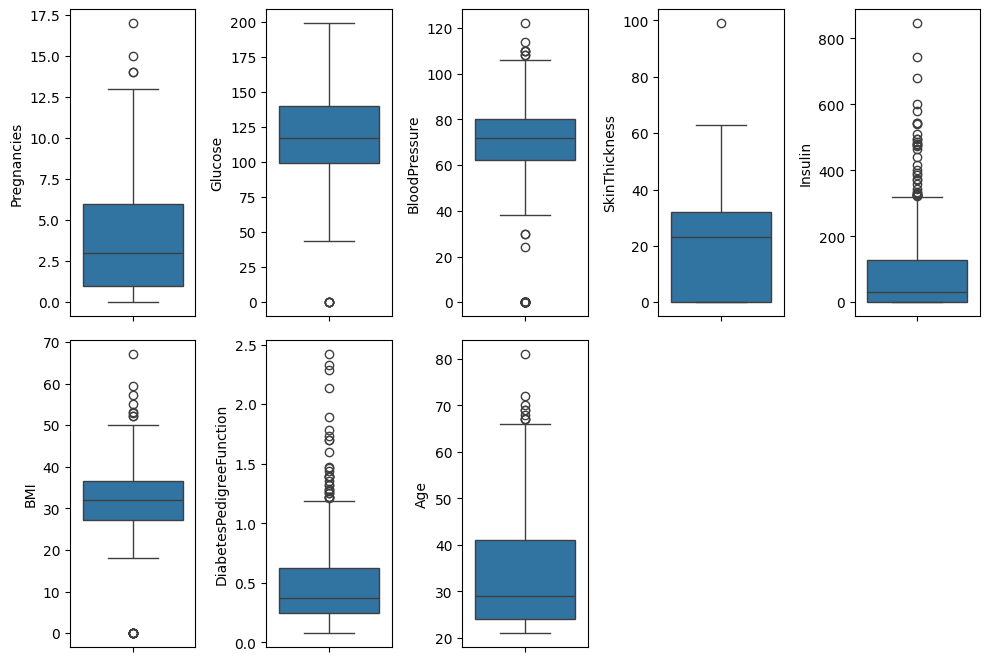

In [20]:
plt.figure(figsize=(10,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

correlation heatmap

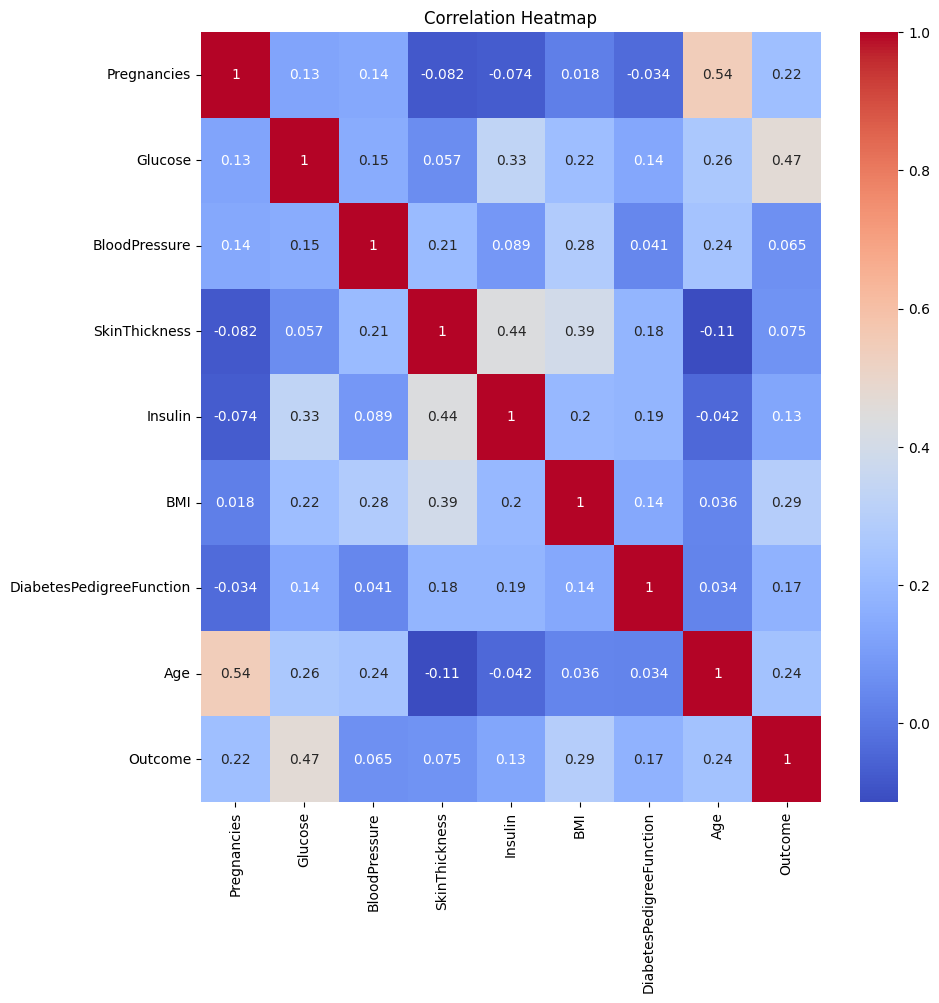

In [21]:
plt.figure(figsize=(10,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

outcome distribution

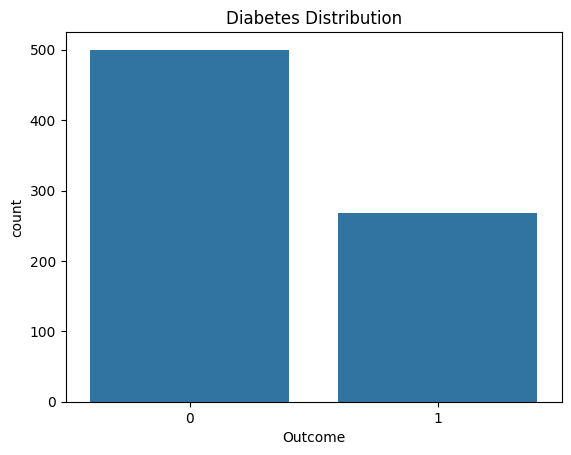

In [22]:
sns.countplot(x='Outcome',data=df)

plt.title("Diabetes Distribution")
plt.show()

scatter plot

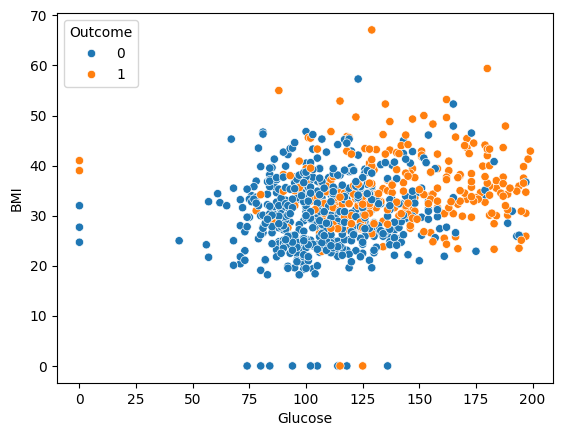

In [24]:
sns.scatterplot(x='Glucose', y='BMI',hue='Outcome',data=df)

plt.show()

data preprocessing

In [25]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0,np.nan)

imputation

In [26]:
imputer=SimpleImputer(strategy="median")

df[cols]=imputer.fit_transform(df[cols])

In [27]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


spliting dataset

In [29]:
X=df.drop("Outcome",axis=1)

y=df["Outcome"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=45,
    stratify=y
)

lightGBM model

In [30]:
lgbm=LGBMClassifier(random_state=42)
lgbm.fit(X_train,y_train)
pred_lgb=lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 134, number of negative: 250
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 490
[LightGBM] [Info] Number of data points in the train set: 384, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348958 -> initscore=-0.623621
[LightGBM] [Info] Start training from score -0.623621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

evaluation

In [31]:
print("Accuracy:",accuracy_score(y_test,pred_lgb))

print("Precision:",precision_score(y_test,pred_lgb))

print("Recall:",recall_score(y_test,pred_lgb))

print("F1 Score:",f1_score(y_test,pred_lgb))

Accuracy: 0.7421875
Precision: 0.6356589147286822
Recall: 0.6119402985074627
F1 Score: 0.623574144486692


calssification report

In [32]:
print(classification_report(y_test,pred_lgb))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       250
           1       0.64      0.61      0.62       134

    accuracy                           0.74       384
   macro avg       0.72      0.71      0.71       384
weighted avg       0.74      0.74      0.74       384



confusion matrix

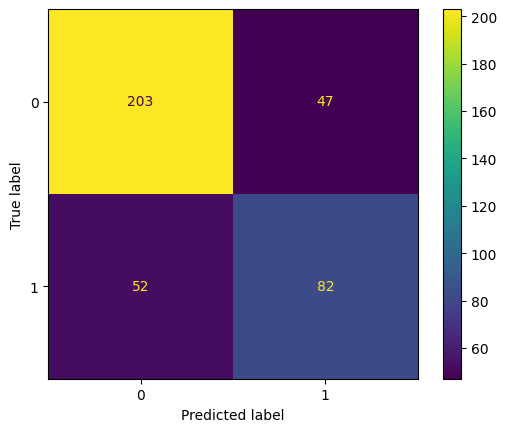

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lgb
)

plt.show()

XGBboost model

In [35]:
xgb=XGBClassifier(
    random_state=45,
    eval_metric="logloss"
)

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

evaluation

In [36]:
print("Accuracy:",
      accuracy_score(y_test,pred_xgb))

print("Precision:",
      precision_score(y_test,pred_xgb))

print("Recall:",
      recall_score(y_test,pred_xgb))

print("F1 Score:",
      f1_score(y_test,pred_xgb))

Accuracy: 0.71875
Precision: 0.5970149253731343
Recall: 0.5970149253731343
F1 Score: 0.5970149253731343


classification report

In [37]:
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       250
           1       0.60      0.60      0.60       134

    accuracy                           0.72       384
   macro avg       0.69      0.69      0.69       384
weighted avg       0.72      0.72      0.72       384



confusion matrix

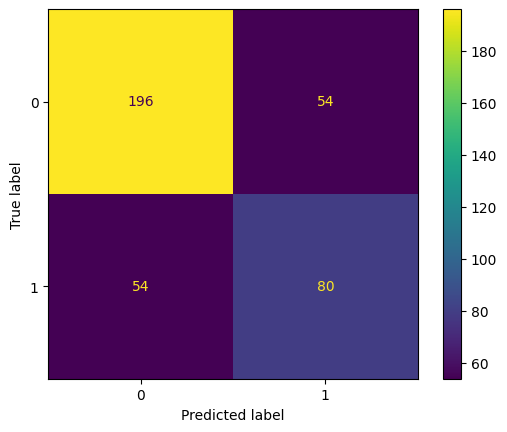

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_xgb
)

plt.show()

cross validation

lightGBM

In [40]:
scores=cross_val_score(
    lgbm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

XGBoost

In [41]:
scores=cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[0.72727273 0.71428571 0.74675325 0.78431373 0.77124183]
0.7487734487734488


hyperparameter tuning

lightGBM

In [43]:
params={
    "n_estimators":[100,200],
    "max_depth":[2,5,8],
    "learning_rate":[0.01,0.05,0.1]
}

grid=GridSearchCV(
    lgbm,
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

lightGBM

In [44]:
params={
    "n_estimators":[100,200],
    "max_depth":[2,5,8],
    "learning_rate":[0.01,0.05,0.1]
}

grid=GridSearchCV(xgb,params,cv=5,scoring="accuracy")

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
0.7916267942583731


feature importance

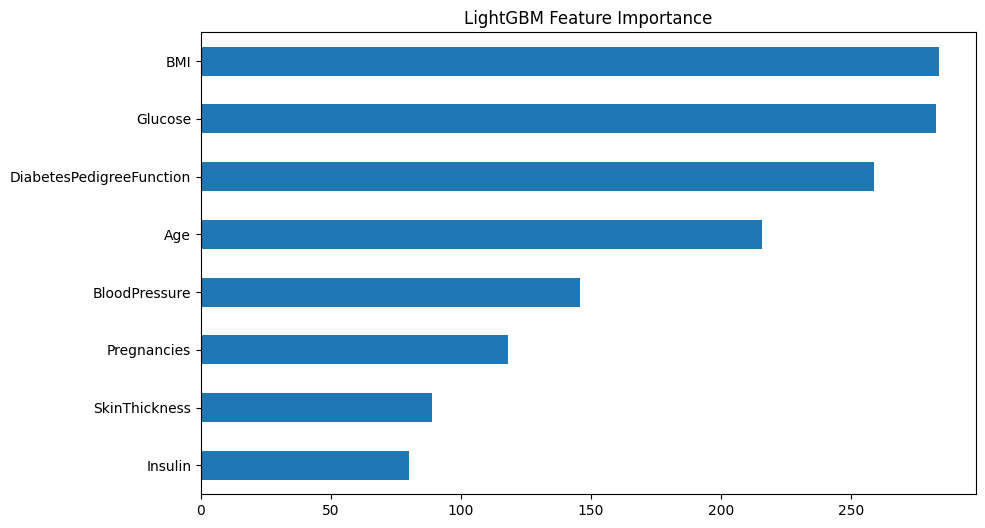

In [48]:
importance=pd.Series(lgbm.feature_importances_,index=X.columns)
importance.sort_values().plot(kind="barh",figsize=(10,6))

plt.title("LightGBM Feature Importance")
plt.show()

XGBoost

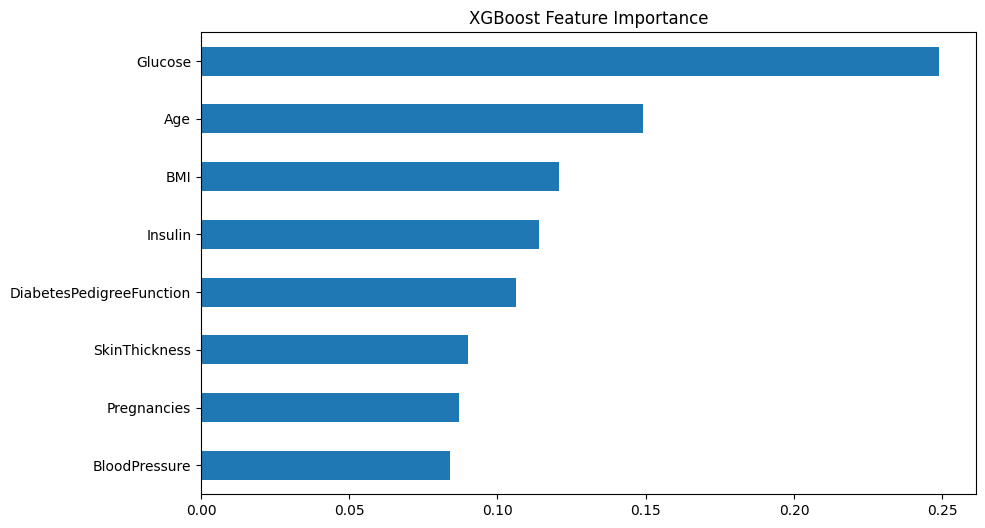

In [47]:
importance=pd.Series(xgb.feature_importances_,index=X.columns)

importance.sort_values().plot(kind="barh",figsize=(10,6))

plt.title("XGBoost Feature Importance")
plt.show()